# Cross-Task Semantic Regression

This notebook extends the cross-task decoding paradigm to regression analysis. We train regressors to map neural activity to word embeddings and evaluate:
1. Within-task regression performance (train and test on same task)
2. Cross-task regression generalization (train on one task, test on another)
3. Ranked accuracy - whether the predicted embedding is close to the correct word

The ranked accuracy metric checks if the true word embedding is among the k-nearest neighbors to the predicted embedding in the embedding space.

In [ ]:
import numpy as np
import scipy.io as sio
import mat73
import os
import sys
import pandas as pd
import collections
from utils.utils import reformat_raw, remove_number, get_channel_colors, reformat
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

print("Libraries imported successfully!")

## Configuration

Set the patient folder and tasks to load. We'll use the same data loading pipeline as the cross-decoding analysis.

In [ ]:
# Configuration
data_folder = 'data'
patient = 'RB'
patient_date = '2024-01-25 RB'

# Tasks to load
tasks_to_load = [
    {'file': 'pictureNaming_all_data.mat', 'task_type': 'picture_naming'},
    {'file': 'pictureFlashing_all_data.mat', 'task_type': 'picture_flashing'},
    {'file': 'auditoryNaming_all_data.mat', 'task_type': 'auditory_naming'},
    {'file': 'auditoryRepetition_all_data.mat', 'task_type': 'auditory_repetition'},
]

# Binning parameters
bin_size = 100  # ms

# Time alignment options
alignment_method = 'time_warp'  # Options: 'time_warp', 'keep_original', 'truncate'
# - 'time_warp': Warp auditory tasks to match visual task timing
# - 'keep_original': Keep original trial lengths (no truncation/warping)
# - 'truncate': Truncate all tasks to minimum length

# Time warping reference (for 'time_warp' method)
# Auditory tasks have longer stimulus presentation, so we warp them to match visual tasks
reference_task = 'picture_naming'  # Use this task's timing as reference

# Bad channels and trials (can be customized per task)
bad_channels = []
bad_trials = []

# Shank selection
shank_of_interest = ['A', 'B', 'C', 'D', 'T', 'U', 'L', 'W', 'O', 'J', 'X', 'Y', 'V', 'Z']

print(f"Patient: {patient}")
print(f"Patient folder: {patient_date}")
print(f"Tasks to load: {[t['task_type'] for t in tasks_to_load]}")
print(f"Alignment method: {alignment_method}")
if alignment_method == 'time_warp':
    print(f"Reference task for warping: {reference_task}")

## Load Word Embeddings

Load pre-computed word embeddings (e.g., from Word2Vec, GloVe, BERT, etc.)

In [ ]:
# Load GloVe word embeddings
print("Loading GloVe embeddings...")

from torchtext.vocab import GloVe
from nltk.stem import WordNetLemmatizer

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Load GloVe embeddings (this may take a moment on first run)
embed = GloVe(dim=300, name='840B')  # 300-dimensional GloVe embeddings

print(f"GloVe embeddings loaded! Vocabulary size: {len(embed.itos)}")
print("Ready to create word embeddings for target words")

## Load Task Data

We'll use the same data loading function from the cross-decoding notebook.

In [ ]:
def load_task_data(task_path, task_type, bin_size=100, bad_channels=[], bad_trials=[], 
                   shank_of_interest=None, word_to_category_dict=None, apply_time_warping=False):
    """
    Load and preprocess data from a single task.
    
    Parameters:
    -----------
    task_path : str
        Path to the .mat file
    task_type : str
        Label for the task type (e.g., 'picture_naming', 'auditory_naming')
        For 'picture_naming_words_aloud', this will be split into 'picture_naming' and 'word_reading'
        based on column 13 (isPicture flag)
    bin_size : int
        Bin size in milliseconds
    bad_channels : list
        Indices of bad channels to remove
    bad_trials : list
        Indices of bad trials to remove
    shank_of_interest : list or None
        List of shank prefixes to keep (e.g., ['A', 'B', 'C'])
    word_to_category_dict : dict or None
        Mapping from words to semantic categories
    apply_time_warping : bool
        Whether to apply linear time warping (for auditory tasks)
    
    Returns:
    --------
    dict with keys:
        - clean_data_binned: neural data (trials x channels x time_bins)
        - clean_trial_onset: trial onset times
        - clean_trial_offset: trial offset times
        - clean_green_screen_onset: go cue times
        - clean_voice_onset: voice onset times
        - clean_voice_offset: voice offset times
        - clean_target_words: target words
        - clean_answered_words: answered words
        - word_categories: semantic categories
        - task_type: task label for each trial
        - channel_names: channel names
        - fs: sampling frequency
        - bin_size: bin size in ms
        - clean_first_word_onset: onset time of the first word for each trial
        - clean_last_word_offset: offset time of the last word for each trial
        - data_binned_warped: time-warped data (if apply_time_warping=True)
        - *_warped: warped timing cues (if apply_time_warping=True)
    """
    print(f"\n{'='*60}")
    print(f"Loading task: {task_type}")
    print(f"File: {task_path}")
    print(f"{'='*60}")
    
    # Load data
    try:
        all_data = np.array(mat73.loadmat(task_path)['all_data'], dtype=object)
    except:
        all_data = sio.loadmat(task_path)['all_data']
    
    # Remove None trials
    all_data = all_data[~np.array([isinstance(a, type(None)) for a in all_data[:, 0]])]
    print(f"Loaded {len(all_data)} trials")
    
    # Extract sampling frequency
    fs = int(all_data[0, 10])
    n_samples_per_bin = fs * bin_size // 1000
    
    # Check if this is the pictureNaming_wordsAloud task (has isPicture flag in column 13)
    is_words_aloud_task = 'words_aloud' in task_type.lower() or 'wordsaloud' in task_type.lower()
    trial_is_picture = None
    
    if is_words_aloud_task and all_data.shape[1] > 13:
        # Column 13 contains isPicture flag (can be 'picture'/'text' strings or 1/0 numbers)
        trial_is_picture = reformat_raw(all_data[:, 13])
        # Convert to boolean, handling both string and numeric formats
        def convert_to_bool(val):
            if isinstance(val, str):
                return val.lower() == 'picture'
            else:
                try:
                    return bool(int(float(val)))
                except:
                    return True  # Default to picture if unclear
        trial_is_picture = np.array([convert_to_bool(val) for val in trial_is_picture])
        print(f"Words Aloud task detected: {np.sum(trial_is_picture)} picture trials, {np.sum(~trial_is_picture)} word reading trials")
    
    # Process target labels
    target_label = reformat_raw(all_data[:, 6])
    
    # Remove picture numbers for flashing and auditory naming
    if 'Flashing' in task_path or 'auditoryNaming' in task_path:
        target_label = np.array([remove_number(t) for t in target_label])
    
    # Get word categories if mapping is provided
    if word_to_category_dict is not None:
        word_category = [word_to_category_dict.get(word[:].lower(), 'unknown') for word in target_label]
        # Merge categories
        word_category = [w if w != 'fruit' and w != 'food (exclude fruit)' else 'food and fruit' for w in word_category]
        word_category = [w if w != 'vehicle' else 'objects and tools' for w in word_category]
    else:
        word_category = ['unknown'] * len(target_label)
    
    print(f"Word category distribution: {collections.Counter(word_category)}")
    
    # Extract timing and data
    data = all_data[:, 0]
    trial_onset = reformat_raw(all_data[:, 1])
    green_screen_onset = reformat_raw(all_data[:, 2])
    trial_offset = reformat_raw(all_data[:, 3])
    voice_onset = reformat_raw(all_data[:, 4])
    voice_offset = reformat_raw(all_data[:, 5])
    answer_label = reformat_raw(all_data[:, 7])
    
    # Load word timing information for auditory tasks (columns 15-16 in Python indexing)
    word_onsets = None
    word_offsets = None
    if 'auditoryNaming' in task_path or 'auditoryRepetition' in task_path:
        if all_data.shape[1] > 16:
            # Column 15: word onset times (list of onsets for each word in stimulus)
            # Column 16: word offset times (list of offsets for each word in stimulus)
            word_onsets = all_data[:, 15]
            word_offsets = all_data[:, 16]
            print(f"Loaded word timing information from columns 15-16")
    
    # Get channel names
    channel_names = all_data[0, 11]
    channel_names = [cn for cn in channel_names]
    
    # Process neural data
    shortest_trial = min([d.shape[0] for d in data])
    data = np.array([np.array([d for d in dt[:shortest_trial]]) for dt in data]).swapaxes(1, 2)
    min_length = data.shape[2] // n_samples_per_bin * n_samples_per_bin
    data = data[:, :, :min_length]
    data_binned = data.reshape(data.shape[0], data.shape[1], -1, n_samples_per_bin).mean(axis=3)
    
    print(f"Data shape before cleaning: {data_binned.shape}")
    
    # Time warping (optional, mainly for auditory tasks)
    data_binned_warped = None
    warped_cues = {}
    
    if apply_time_warping and word_onsets is not None and word_offsets is not None:
        print("\nApplying linear time warping based on word boundaries...")
        
        # Calculate trial durations based on first word onset to last word offset
        trial_durations = []
        first_word_onsets = []
        last_word_offsets = []
        
        for i in range(len(data)):
            # Extract word timing for this trial
            trial_word_onsets = word_onsets[i]
            trial_word_offsets = word_offsets[i]
            
            # Handle different data formats (list, array, or scalar)
            if isinstance(trial_word_onsets, (list, np.ndarray)):
                if len(trial_word_onsets) > 0:
                    first_word_onset = float(trial_word_onsets[0])
                    last_word_offset = float(trial_word_offsets[-1])
                else:
                    # Fallback to trial onset/offset if no words
                    first_word_onset = trial_onset[i]
                    last_word_offset = trial_offset[i]
            else:
                # Single word case
                first_word_onset = float(trial_word_onsets)
                last_word_offset = float(trial_word_offsets)
            
            first_word_onsets.append(first_word_onset)
            last_word_offsets.append(last_word_offset)
            
            onset_idx = int(np.round(first_word_onset * fs))
            offset_idx = int(np.round(last_word_offset * fs))
            duration = offset_idx - onset_idx
            trial_durations.append(duration)
        
        trial_durations = np.array(trial_durations)
        median_duration = int(np.median(trial_durations))
        
        print(f"Word-based durations: min={trial_durations.min()/fs:.3f}s, max={trial_durations.max()/fs:.3f}s, median={median_duration/fs:.3f}s")
        
        # Warp each trial
        data_warped = []
        trial_onset_warped = []
        first_word_onset_warped = []
        last_word_offset_warped = []
        trial_offset_warped = []
        green_screen_onset_warped = []
        voice_onset_warped = []
        voice_offset_warped = []
        
        for i in range(len(data)):
            trial = data[i]
            onset_idx = int(np.round(first_word_onsets[i] * fs))
            offset_idx = int(np.round(last_word_offsets[i] * fs))
            
            pre_onset = trial[:, :onset_idx]
            during_trial = trial[:, onset_idx:offset_idx]
            post_offset = trial[:, offset_idx:]
            
            # Warp during-trial segment
            original_time = np.arange(during_trial.shape[1])
            warped_time = np.linspace(0, during_trial.shape[1] - 1, median_duration)
            
            during_trial_warped = np.zeros((trial.shape[0], median_duration))
            for ch in range(trial.shape[0]):
                interpolator = interp1d(original_time, during_trial[ch, :], kind='linear', fill_value='extrapolate')
                during_trial_warped[ch, :] = interpolator(warped_time)
            
            trial_warped = np.concatenate([pre_onset, during_trial_warped, post_offset], axis=1)
            data_warped.append(trial_warped)
            
            # Adjust timing cues
            trial_onset_warped.append(trial_onset[i])
            new_first_word_onset = first_word_onsets[i]
            new_last_word_offset = (onset_idx + median_duration) / fs
            first_word_onset_warped.append(new_first_word_onset)
            last_word_offset_warped.append(new_last_word_offset)
            trial_offset_warped.append(new_last_word_offset)
            
            def warp_cue(cue_time):
                cue_idx = cue_time * fs
                if cue_idx < onset_idx:
                    return cue_time
                elif cue_idx > offset_idx:
                    shift = (median_duration - (offset_idx - onset_idx)) / fs
                    return cue_time + shift
                else:
                    relative_position = (cue_idx - onset_idx) / (offset_idx - onset_idx)
                    new_cue_idx = onset_idx + relative_position * median_duration
                    return new_cue_idx / fs
            
            green_screen_onset_warped.append(warp_cue(green_screen_onset[i]))
            voice_onset_warped.append(warp_cue(voice_onset[i]))
            voice_offset_warped.append(warp_cue(voice_offset[i]))
        
        # Standardize lengths and bin
        shortest_warped = min([d.shape[1] for d in data_warped])
        data_warped = np.array([d[:, :shortest_warped] for d in data_warped])
        min_length_warped = data_warped.shape[2] // n_samples_per_bin * n_samples_per_bin
        data_warped = data_warped[:, :, :min_length_warped]
        data_binned_warped = data_warped.reshape(data_warped.shape[0], data_warped.shape[1], -1, n_samples_per_bin).mean(axis=3)
        
        warped_cues = {
            'trial_onset': np.array(trial_onset_warped),
            'first_word_onset': np.array(first_word_onset_warped),
            'last_word_offset': np.array(last_word_offset_warped),
            'trial_offset': np.array(trial_offset_warped),
            'green_screen_onset': np.array(green_screen_onset_warped),
            'voice_onset': np.array(voice_onset_warped),
            'voice_offset': np.array(voice_offset_warped)
        }
        
        print(f"Warped data shape: {data_binned_warped.shape}")
    
    # Remove bad channels and trials
    clean_data_binned = np.delete(np.delete(data_binned, bad_channels, axis=1), bad_trials, axis=0)
    clean_channel_names = np.delete(channel_names, bad_channels, axis=0)
    
    clean_trial_onset = np.delete(trial_onset, bad_trials)
    clean_trial_offset = np.delete(trial_offset, bad_trials)
    clean_green_screen_onset = np.delete(green_screen_onset, bad_trials)
    clean_voice_onset = np.delete(voice_onset, bad_trials)
    clean_voice_offset = np.delete(voice_offset, bad_trials)
    clean_target_label = np.delete(target_label, bad_trials)
    clean_answer_label = np.delete(answer_label, bad_trials)
    clean_word_category = [word_category[i] for i in range(len(word_category)) if i not in bad_trials]
    
    # Clean word timing if it exists
    clean_first_word_onset = None
    clean_last_word_offset = None
    if word_onsets is not None and word_offsets is not None:
        # Extract first and last word times for each trial
        first_word_onset_list = []
        last_word_offset_list = []
        for i in range(len(word_onsets)):
            trial_word_onsets = word_onsets[i]
            trial_word_offsets = word_offsets[i]
            
            if isinstance(trial_word_onsets, (list, np.ndarray)):
                if len(trial_word_onsets) > 0:
                    first_word_onset_list.append(float(trial_word_onsets[0]))
                    last_word_offset_list.append(float(trial_word_offsets[-1]))
                else:
                    first_word_onset_list.append(trial_onset[i])
                    last_word_offset_list.append(trial_offset[i])
            else:
                first_word_onset_list.append(float(trial_word_onsets))
                last_word_offset_list.append(float(trial_word_offsets))
        
        clean_first_word_onset = np.delete(np.array(first_word_onset_list), bad_trials)
        clean_last_word_offset = np.delete(np.array(last_word_offset_list), bad_trials)
    
    # Clean warped data if it exists
    if data_binned_warped is not None:
        clean_data_binned_warped = np.delete(np.delete(data_binned_warped, bad_channels, axis=1), bad_trials, axis=0)
        for key in warped_cues:
            warped_cues[key] = np.delete(warped_cues[key], bad_trials)
    else:
        clean_data_binned_warped = None
    
    # Filter by shank if specified
    if shank_of_interest is not None:
        shank_mask = [i for i, cn in enumerate(clean_channel_names) if cn[0] in shank_of_interest]
        clean_data_binned = clean_data_binned[:, shank_mask, :]
        clean_channel_names = [clean_channel_names[i] for i in shank_mask]
        if clean_data_binned_warped is not None:
            clean_data_binned_warped = clean_data_binned_warped[:, shank_mask, :]
    
    print(f"Data shape after cleaning: {clean_data_binned.shape}")
    print(f"Number of channels: {len(clean_channel_names)}")
    print(f"Number of trials: {clean_data_binned.shape[0]}")
    
    # Create task type labels
    # For words_aloud task, create separate labels for picture vs word reading trials
    if is_words_aloud_task and trial_is_picture is not None:
        # Remove bad trials from trial_is_picture flag
        clean_trial_is_picture = np.delete(trial_is_picture, bad_trials)
        task_labels = ['picture_naming' if is_pic else 'word_reading' for is_pic in clean_trial_is_picture]
        print(f"Task labels: {collections.Counter(task_labels)}")
    else:
        task_labels = [task_type] * clean_data_binned.shape[0]
    
    # Package results
    result = {
        'clean_data_binned': clean_data_binned,
        'clean_trial_onset': clean_trial_onset,
        'clean_trial_offset': clean_trial_offset,
        'clean_green_screen_onset': clean_green_screen_onset,
        'clean_voice_onset': clean_voice_onset,
        'clean_voice_offset': clean_voice_offset,
        'clean_target_words': clean_target_label,
        'clean_answered_words': clean_answer_label,
        'word_categories': clean_word_category,
        'task_type': task_labels,
        'channel_names': clean_channel_names,
        'fs': fs,
        'bin_size': bin_size,
        'clean_first_word_onset': clean_first_word_onset,
        'clean_last_word_offset': clean_last_word_offset
    }
    
    if clean_data_binned_warped is not None:
        result['clean_data_binned_warped'] = clean_data_binned_warped
        result.update({f'{k}_warped': v for k, v in warped_cues.items()})
    
    return result

In [ ]:
def time_warp_trials(data, first_word_onsets, last_word_offsets, fs=512, bin_size=100):
    """
    Apply linear time warping to neural data to align stimulus presentation periods.
    
    Warps the period between first word onset and last word offset to match a target duration.
    Based on the approach in semantics.ipynb.
    
    Parameters:
    -----------
    data : np.ndarray
        Neural data with shape (n_trials, n_channels, n_time_bins)
    first_word_onsets : np.ndarray
        Time of first word onset for each trial (in seconds)
    last_word_offsets : np.ndarray
        Time of last word offset for each trial (in seconds)
    fs : int
        Sampling frequency (Hz)
    bin_size : int
        Bin size in milliseconds
    
    Returns:
    --------
    np.ndarray
        Time-warped data with same shape as input
    """
    from scipy.interpolate import interp1d
    
    n_trials, n_channels, n_time_bins = data.shape
    n_samples_per_bin = fs * bin_size // 1000
    
    # Calculate target duration in samples
    print(f"Time warping {n_trials} trials...")

    
    # Warp each trial
    warped_trials = []
    
    for i in range(n_trials):
        # Get original onset and offset indices
        onset_idx = int(np.round(first_word_onsets[i] * fs))
        offset_idx = int(np.round(last_word_offsets[i] * fs))

        target_duration = offset_idx - onset_idx
        
        # Reconstruct unbinned trial (approximate by repeating bin values)
        trial_unbinned = np.repeat(data[i], n_samples_per_bin, axis=1)
        
        # Split into pre-onset, during-stimulus, and post-offset segments
        pre_onset = trial_unbinned[:, :onset_idx]
        during_stimulus = trial_unbinned[:, onset_idx:offset_idx]
        post_offset = trial_unbinned[:, offset_idx:]
        
        # Warp the during-stimulus segment
        original_time = np.arange(during_stimulus.shape[1])
        warped_time = np.linspace(0, during_stimulus.shape[1] - 1, target_duration)
        
        during_stimulus_warped = np.zeros((n_channels, target_duration))
        for ch in range(n_channels):
            interpolator = interp1d(original_time, during_stimulus[ch, :], 
                                   kind='linear', fill_value='extrapolate')
            during_stimulus_warped[ch, :] = interpolator(warped_time)
        
        # Concatenate segments
        trial_warped = np.concatenate([pre_onset, during_stimulus_warped, post_offset], axis=1)
        warped_trials.append(trial_warped)
    
    # Find shortest warped trial
    shortest_warped = min([t.shape[1] for t in warped_trials])
    warped_trials = np.array([t[:, :shortest_warped] for t in warped_trials])
    
    # Re-bin the warped data
    min_length_warped = warped_trials.shape[2] // n_samples_per_bin * n_samples_per_bin
    warped_trials = warped_trials[:, :, :min_length_warped]
    warped_binned = warped_trials.reshape(n_trials, n_channels, -1, n_samples_per_bin).mean(axis=3)
    
    print(f"  Warped data shape: {warped_binned.shape}")
    
    return warped_binned

In [ ]:
# Load all tasks
task_data_dict = {}

for task_info in tasks_to_load:
    task_file = task_info['file']
    task_type = task_info['task_type']
    task_path = os.path.join(data_folder, patient_date, task_file)
    
    if not os.path.exists(task_path):
        print(f"WARNING: File not found: {task_path}")
        continue
    
    try:
        task_data = load_task_data(
            task_path=task_path,
            task_type=task_type,
            bin_size=bin_size,
            bad_channels=bad_channels,
            bad_trials=bad_trials,
            shank_of_interest=shank_of_interest,
            apply_time_warping=True  # Will apply later based on alignment_method
        )
        task_data_dict[task_type] = task_data
        print(f"âœ“ Successfully loaded {task_type}")
    except Exception as e:
        print(f"âœ— Error loading {task_type}: {str(e)}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*60}")
print(f"Loaded {len(task_data_dict)} tasks successfully")
print(f"Tasks: {list(task_data_dict.keys())}")
print(f"{'='*60}")

In [ ]:
# Create word embeddings for all words across tasks using GloVe
all_words = []
for task_type, task_data in task_data_dict.items():
    all_words.extend(task_data['clean_target_words'])

# Get unique words
unique_words = list(set(all_words))
print(f"Found {len(unique_words)} unique words across all tasks")

# Lemmatize words and create embeddings
word_to_embedding = {}
missing_words = []

for word in unique_words:
    if word == 'NA' or word is None:
        continue
    
    # Lemmatize the word (remove non-alpha characters and lemmatize as noun)
    lemmatized = lemmatizer.lemmatize(''.join([char for char in word if char.isalpha()]), pos='n')
    
    # Get GloVe embedding
    try:
        word_to_embedding[word] = embed[lemmatized].numpy()
    except KeyError:
        # Try original word if lemmatized version not found
        try:
            word_to_embedding[word] = embed[word].numpy()
        except KeyError:
            missing_words.append(word)
            print(f"Warning: No embedding found for '{word}' (lemmatized: '{lemmatized}')")

print(f"\nCreated embeddings for {len(word_to_embedding)}/{len(unique_words)} words")
print(f"Missing embeddings: {len(missing_words)} words")
if len(missing_words) > 0:
    print(f"Missing words: {missing_words[:10]}{'...' if len(missing_words) > 10 else ''}")

# Add embeddings to each task
for task_type, task_data in task_data_dict.items():
    embeddings = []
    for word in task_data['clean_target_words']:
        if word in word_to_embedding and word != 'NA':
            embeddings.append(word_to_embedding[word])
        else:
            embeddings.append(None)
    task_data['embeddings'] = np.array(embeddings, dtype=object)
    
    # Count valid embeddings per task
    valid_count = sum(1 for e in embeddings if e is not None)
    print(f"{task_type}: {valid_count}/{len(embeddings)} trials have valid embeddings")

print(f"\nEmbedding dimension: {list(word_to_embedding.values())[0].shape[0]}")

In [ ]:
# Apply time alignment based on selected method
print(f"\nApplying alignment method: {alignment_method}")
print("="*60)

if alignment_method == 'time_warp':
    # Time warp auditory tasks to match reference task timing
    if reference_task not in task_data_dict:
        print(f"WARNING: Reference task '{reference_task}' not found. Using first task as reference.")
        reference_task = list(task_data_dict.keys())[0]
    
    ref_data = task_data_dict[reference_task]
    ref_onset = np.nanmean(ref_data['clean_green_screen_onset'] - ref_data['clean_trial_onset'])
    ref_voice_onset = np.nanmean(ref_data['clean_voice_onset'] - ref_data['clean_trial_onset'])
    
    print(f"Reference task: {reference_task}")
    print(f"  Mean go cue onset: {ref_onset:.3f}s")
    print(f"  Mean voice onset: {ref_voice_onset:.3f}s")
    
    for task_type, task_data in task_data_dict.items():
        if 'auditory_naming' in task_type.lower():
            print(f"\nWarping {task_type}...")
            first_word_onsets=reformat_raw(task_data['clean_first_word_onset'])
            last_word_offsets=reformat_raw(task_data['clean_last_word_offset'])
            #first_word_onsets = [o[0] for o in first_word_onsets]
            #last_word_offsets = [o[-1] for o in last_word_offsets]
            # Warp to reference timing
            warped_data = time_warp_trials(
                data=task_data['clean_data_binned'],
                first_word_onsets=first_word_onsets,
                last_word_offsets=last_word_offsets,
                fs=task_data['fs'],
                bin_size=task_data['bin_size']

            )
            
            task_data['clean_data_binned_warped'] = warped_data
            task_data['clean_data_binned_original'] = task_data['clean_data_binned'].copy()
            task_data['clean_data_binned'] = warped_data  # Use warped by default
            
            print(f"  âœ“ Warped to reference timing")
        else:
            print(f"\n{task_type}: No warping needed (visual task)")
            task_data['clean_data_binned_warped'] = None
            task_data['clean_data_binned_original'] = task_data['clean_data_binned'].copy()

elif alignment_method == 'truncate':
    # Truncate all tasks to minimum length
    min_time_bins = min([task_data['clean_data_binned'].shape[2] 
                         for task_data in task_data_dict.values()])
    min_channels = min([task_data['clean_data_binned'].shape[1] 
                        for task_data in task_data_dict.values()])
    
    print(f"Truncating to: {min_channels} channels, {min_time_bins} time bins")
    
    for task_type, task_data in task_data_dict.items():
        original_shape = task_data['clean_data_binned'].shape
        task_data['clean_data_binned_original'] = task_data['clean_data_binned'].copy()
        task_data['clean_data_binned'] = task_data['clean_data_binned'][:, :min_channels, :min_time_bins]
        print(f"  {task_type}: {original_shape} â†’ {task_data['clean_data_binned'].shape}")

elif alignment_method == 'keep_original':
    # Keep original lengths
    print("Keeping original trial lengths for each task")
    print("Note: Cross-task analysis will require per-task processing")
    
    for task_type, task_data in task_data_dict.items():
        shape = task_data['clean_data_binned'].shape
        task_data['clean_data_binned_original'] = task_data['clean_data_binned'].copy()
        print(f"  {task_type}: {shape[0]} trials, {shape[1]} channels, {shape[2]} time bins")

print("\n" + "="*60)
print("Alignment complete!")

In [ ]:
# Display summary statistics for each task
summary_data = []
for task_type, task_data in task_data_dict.items():
    # Count valid embeddings
    valid_embeddings = sum([1 for emb in task_data['embeddings'] if emb is not None])
    
    # Get timing info
    mean_trial_length = np.nanmean(task_data['clean_trial_offset'] - task_data['clean_trial_onset'])
    mean_voice_onset = np.nanmean(task_data['clean_voice_onset'] - task_data['clean_trial_onset'])
    
    summary_data.append({
        'Task': task_type,
        'N Trials': task_data['clean_data_binned'].shape[0],
        'N Channels': task_data['clean_data_binned'].shape[1],
        'N Time Bins': task_data['clean_data_binned'].shape[2],
        'Valid Embeddings': valid_embeddings,
        'Mean Trial Length (s)': f"{mean_trial_length:.2f}",
        'Mean Voice Onset (s)': f"{mean_voice_onset:.2f}",
        'Is Warped': task_data['clean_data_binned_warped'] is not None
    })

summary_df = pd.DataFrame(summary_data)
print("\nTask Summary:")
print(summary_df.to_string(index=False))

# Check for task-specific characteristics
print("\nTask Characteristics:")
for task_type in task_data_dict.keys():
    if 'auditory' in task_type.lower():
        print(f"  {task_type}: Auditory task (longer stimulus presentation)")
    else:
        print(f"  {task_type}: Visual task (shorter, consistent timing)")

## Prepare Regression Data

Extract neural data and corresponding word embeddings for regression analysis.

In [ ]:
# Extract task data for regression analysis
# You can select which tasks to use for within-task and cross-task analysis

# Example 1: Picture Flashing vs Picture Naming (visual tasks only)
if 'picture_flashing' in task_data_dict and 'picture_naming' in task_data_dict:
    pf_data = task_data_dict['picture_flashing']
    pn_data = task_data_dict['picture_naming']
    
    # Get neural data and embeddings (swap axes: trials x time_bins x channels)
    pf_neural = pf_data['clean_data_binned'].swapaxes(1, 2)
    pf_embeddings = np.array([emb for emb in pf_data['embeddings'] if emb is not None])
    pf_words = pf_data['clean_target_words'][[emb is not None for emb in pf_data['embeddings']]]
    
    pn_neural = pn_data['clean_data_binned'].swapaxes(1, 2)
    pn_embeddings = np.array([emb for emb in pn_data['embeddings'] if emb is not None])
    pn_words = pn_data['clean_target_words'][[emb is not None for emb in pn_data['embeddings']]]
    
    print("Visual Tasks Loaded:")
    print(f"  Picture Flashing: {pf_neural.shape}, {len(pf_embeddings)} valid embeddings")
    print(f"  Picture Naming: {pn_neural.shape}, {len(pn_embeddings)} valid embeddings")

# Example 2: Auditory Naming vs Picture Naming (cross-modality)
if 'auditory_naming' in task_data_dict and 'picture_naming' in task_data_dict:
    an_data = task_data_dict['auditory_naming']
    pn_data = task_data_dict['picture_naming']
    
    an_neural = an_data['clean_data_binned'].swapaxes(1, 2)
    an_embeddings = np.array([emb for emb in an_data['embeddings'] if emb is not None])
    an_words = an_data['clean_target_words'][[emb is not None for emb in an_data['embeddings']]]
    
    print("\nCross-Modality Tasks Loaded:")
    print(f"  Auditory Naming: {an_neural.shape}, {len(an_embeddings)} valid embeddings")
    if alignment_method == 'time_warp':
        print(f"    (Time-warped to match visual task timing)")
    print(f"  Picture Naming: {pn_neural.shape}, {len(pn_embeddings)} valid embeddings")

# Example 3: Auditory Repetition vs Auditory Naming
if 'auditory_repetition' in task_data_dict and 'auditory_naming' in task_data_dict:
    ar_data = task_data_dict['auditory_repetition']
    an_data = task_data_dict['auditory_naming']
    
    ar_neural = ar_data['clean_data_binned'].swapaxes(1, 2)
    ar_embeddings = np.array([emb for emb in ar_data['embeddings'] if emb is not None])
    ar_words = ar_data['clean_target_words'][[emb is not None for emb in ar_data['embeddings']]]
    
    print("\nAuditory Tasks Loaded:")
    print(f"  Auditory Repetition: {ar_neural.shape}, {len(ar_embeddings)} valid embeddings")
    print(f"  Auditory Naming: {an_neural.shape}, {len(an_embeddings)} valid embeddings")

print("\nData preparation complete! Ready for regression analysis.")

## Within-Task Regression

Train and test regressors within each task to establish baseline performance.

In [ ]:
# Import regression libraries
from sklearn.linear_model import Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from models.model import BasicRegressor
from utils.utils import plot_accuracy_plotly

print("Regression libraries imported!")

In [ ]:
# Regression parameters
n_bins_history = 5  # Number of bins of history to use
n_splits = 5  # Number of K-fold splits
use_kfold = False  # Use K-fold cross-validation
n_epochs = 10  # Number of random epochs

# Regressor configuration
alpha = 1.0  # Ridge regularization parameter
n_pca_components = 10  # PCA components for dimensionality reduction

# Ranked accuracy parameters
compute_ranked_accuracy = True
top_k_values = [1, 3, 5, 10, 20]  # Top-k values for ranked accuracy

print(f"Regression parameters:")
print(f"  Bins of history: {n_bins_history}")
print(f"  K-fold splits: {n_splits}")
print(f"  Epochs: {n_epochs}")
print(f"  Ridge alpha: {alpha}")
print(f"  PCA components: {n_pca_components}")
print(f"  Top-k values: {top_k_values}")

In [ ]:
# Train regressor on Picture Flashing data
print("Training regressor on Picture Flashing data...")

# Setup regressor
y_reducer = PCA(n_components=n_pca_components)  # Reduce word embedding dimensionality
x_reducer = None  # Keep embeddings as is
regressor = KernelRidge(alpha=alpha, kernel='rbf')

br_pf = BasicRegressor(regressor, x_reducer=x_reducer, y_reducer=y_reducer)
br_pf.load_data(pf_neural, pf_embeddings, n_bins_history=n_bins_history)
br_pf.fit(
    n_epochs=n_epochs, 
    parallel=None, 
    closest='l2',
    use_kfold=use_kfold, 
    n_splits=n_splits,
    compute_top_k_accuracy=compute_ranked_accuracy,
    top_k_values=top_k_values
)

print(f"âœ“ Picture Flashing regressor trained!")
print(f"  Results shape: {br_pf.all_test_score.shape} (epochs x time_bins)")
print(f"  Top-1 accuracy shape: {br_pf.all_top_k_accuracy[1].shape}")

In [ ]:
# Train regressor on Picture Naming data
print("Training regressor on Picture Naming data...")

y_reducer_pn = PCA(n_components=n_pca_components)
x_reducer_pn = None
regressor_pn = KernelRidge(alpha=alpha, kernel='rbf')

br_pn = BasicRegressor(regressor_pn, x_reducer=x_reducer_pn, y_reducer=y_reducer_pn)
br_pn.load_data(pn_neural, pn_embeddings, n_bins_history=n_bins_history)
br_pn.fit(
    n_epochs=n_epochs, 
    parallel=None, 
    closest='l2',
    use_kfold=use_kfold, 
    n_splits=n_splits,
    compute_top_k_accuracy=compute_ranked_accuracy,
    top_k_values=top_k_values
)

print(f"âœ“ Picture Naming regressor trained!")

## Visualize Within-Task Performance

Plot RÂ² scores and top-K accuracy for both trained models.

In [ ]:
# Extract results from trained models
print("Preparing visualization data...")

# Get mean and std across epochs
pf_r2_mean = br_pf.all_test_score.mean(0)
pf_r2_std = br_pf.all_test_score.std(0)

pn_r2_mean = br_pn.all_test_score.mean(0)
pn_r2_std = br_pn.all_test_score.std(0)

# Timing parameters for each task
pf_n_bins = len(pf_r2_mean)
pf_back = np.nanmean(pf_data['clean_trial_onset'])
pf_forward = pf_n_bins*bin_size/1000-np.nanmean(pf_data['clean_trial_onset'])

pn_n_bins = len(pn_r2_mean)
pn_back = np.nanmean(pn_data['clean_trial_onset'])
pn_forward =  pn_n_bins*bin_size/1000-np.nanmean(pn_data['clean_trial_onset'])

print(f"Picture Flashing - Time bins: {pf_n_bins}, Time range: {pf_back:.2f}s to {pf_forward:.2f}s")
print(f"Picture Naming - Time bins: {pn_n_bins}, Time range: {pn_back:.2f}s to {pn_forward:.2f}s")

# Plot Picture Flashing RÂ² scores
print("\nPlotting Picture Flashing RÂ² scores...")
fig_pf_r2, ax_pf_r2 = plot_accuracy_plotly(
    pf_r2_mean,
    data_std=pf_r2_std,
    back=pf_back,
    forward=pf_forward,
    lines=[0],
    line_labels=['Trial Onset'],
    tick_interval=0.5,
    title="Picture Flashing: RÂ² Scores Over Time",
    ylabel="RÂ² Score",
    data_labels=['Picture Flashing']
)
fig_pf_r2.show()

# Plot Picture Naming RÂ² scores
print("Plotting Picture Naming RÂ² scores...")
fig_pn_r2, ax_pn_r2 = plot_accuracy_plotly(
    pn_r2_mean,
    data_std=pn_r2_std,
    back=pn_back,
    forward=pn_forward,
    lines=[0],
    line_labels=['Trial Onset'],
    tick_interval=0.5,
    title="Picture Naming: RÂ² Scores Over Time",
    ylabel="RÂ² Score",
    data_labels=['Picture Naming']
)
fig_pn_r2.show()

# Print peak RÂ² scores
print("\n" + "="*60)
print("Peak RÂ² Scores:")
print("="*60)
pf_peak_r2 = pf_r2_mean.max()
pf_peak_bin_r2 = pf_r2_mean.argmax()
pf_peak_time_r2 = pf_peak_bin_r2 * bin_size / 1000

pn_peak_r2 = pn_r2_mean.max()
pn_peak_bin_r2 = pn_r2_mean.argmax()
pn_peak_time_r2 = pn_peak_bin_r2 * bin_size / 1000

print(f"Picture Flashing: RÂ² = {pf_peak_r2:.3f} at bin {pf_peak_bin_r2} (t = {pf_peak_time_r2:.2f}s)")
print(f"Picture Naming:   RÂ² = {pn_peak_r2:.3f} at bin {pn_peak_bin_r2} (t = {pn_peak_time_r2:.2f}s)")
print("="*60)

In [ ]:
# Plot Top-1 accuracy
print("Plotting Top-1 accuracy...")

pf_top1_mean = br_pf.all_top_k_accuracy[1].mean(0)
pf_top1_std = br_pf.all_top_k_accuracy[1].std(0)

pn_top1_mean = br_pn.all_top_k_accuracy[1].mean(0)
pn_top1_std = br_pn.all_top_k_accuracy[1].std(0)

# Plot Picture Flashing Top-1
print("Plotting Picture Flashing Top-1 accuracy...")
fig_pf_top1, ax_pf_top1 = plot_accuracy_plotly(
    pf_top1_mean,
    data_std=pf_top1_std,
    back=pf_back,
    forward=pf_forward,
    lines=[0],
    line_labels=['Trial Onset'],
    tick_interval=0.5,
    title="Picture Flashing: Top-1 Accuracy Over Time",
    ylabel="Top-1 Accuracy",
    data_labels=['Picture Flashing']
)
fig_pf_top1.show()

# Plot Picture Naming Top-1
print("Plotting Picture Naming Top-1 accuracy...")
fig_pn_top1, ax_pn_top1 = plot_accuracy_plotly(
    pn_top1_mean,
    data_std=pn_top1_std,
    back=pn_back,
    forward=pn_forward,
    lines=[0],
    line_labels=['Trial Onset'],
    tick_interval=0.5,
    title="Picture Naming: Top-1 Accuracy Over Time",
    ylabel="Top-1 Accuracy",
    data_labels=['Picture Naming']
)
fig_pn_top1.show()

# Print peak Top-1 accuracies
print("\n" + "="*60)
print("Peak Top-1 Accuracies:")
print("="*60)
pf_peak_top1 = pf_top1_mean.max()
pf_peak_bin_top1 = pf_top1_mean.argmax()
pf_peak_time_top1 = pf_peak_bin_top1 * bin_size / 1000

pn_peak_top1 = pn_top1_mean.max()
pn_peak_bin_top1 = pn_top1_mean.argmax()
pn_peak_time_top1 = pn_peak_bin_top1 * bin_size / 1000

print(f"Picture Flashing: Acc = {pf_peak_top1:.3f} at bin {pf_peak_bin_top1} (t = {pf_peak_time_top1:.2f}s)")
print(f"Picture Naming:   Acc = {pn_peak_top1:.3f} at bin {pn_peak_bin_top1} (t = {pn_peak_time_top1:.2f}s)")
print("="*60)

In [ ]:
# Plot Top-5 accuracy
print("Plotting Top-5 accuracy...")

pf_top5_mean = br_pf.all_top_k_accuracy[5].mean(0)
pf_top5_std = br_pf.all_top_k_accuracy[5].std(0)

pn_top5_mean = br_pn.all_top_k_accuracy[5].mean(0)
pn_top5_std = br_pn.all_top_k_accuracy[5].std(0)

# Plot Picture Flashing Top-5
print("Plotting Picture Flashing Top-5 accuracy...")
fig_pf_top5, ax_pf_top5 = plot_accuracy_plotly(
    pf_top5_mean,
    data_std=pf_top5_std,
    back=pf_back,
    forward=pf_forward,
    lines=[0],
    line_labels=['Trial Onset'],
    tick_interval=0.5,
    title="Picture Flashing: Top-5 Accuracy Over Time",
    ylabel="Top-5 Accuracy",
    data_labels=['Picture Flashing']
)
fig_pf_top5.show()

# Plot Picture Naming Top-5
print("Plotting Picture Naming Top-5 accuracy...")
fig_pn_top5, ax_pn_top5 = plot_accuracy_plotly(
    pn_top5_mean,
    data_std=pn_top5_std,
    back=pn_back,
    forward=pn_forward,
    lines=[0],
    line_labels=['Trial Onset'],
    tick_interval=0.5,
    title="Picture Naming: Top-5 Accuracy Over Time",
    ylabel="Top-5 Accuracy",
    data_labels=['Picture Naming']
)
fig_pn_top5.show()

# Print peak Top-5 accuracies
print("\n" + "="*60)
print("Peak Top-5 Accuracies:")
print("="*60)
pf_peak_top5 = pf_top5_mean.max()
pf_peak_bin_top5 = pf_top5_mean.argmax()
pf_peak_time_top5 = pf_peak_bin_top5 * bin_size / 1000

pn_peak_top5 = pn_top5_mean.max()
pn_peak_bin_top5 = pn_top5_mean.argmax()
pn_peak_time_top5 = pn_peak_bin_top5 * bin_size / 1000

print(f"Picture Flashing: Acc = {pf_peak_top5:.3f} at bin {pf_peak_bin_top5} (t = {pf_peak_time_top5:.2f}s)")
print(f"Picture Naming:   Acc = {pn_peak_top5:.3f} at bin {pn_peak_bin_top5} (t = {pn_peak_time_top5:.2f}s)")
print("="*60)

In [ ]:
# Compare all Top-K values for Picture Flashing
print("Comparing all Top-K values for Picture Flashing...")

pf_topk_data = [br_pf.all_top_k_accuracy[k].mean(0) for k in top_k_values]
pf_topk_labels = [f'Top-{k}' for k in top_k_values]

fig_pf_topk, ax_pf_topk = plot_accuracy_plotly(
    pf_topk_data[0],
    *pf_topk_data[1:],
    back=pf_back,
    forward=pf_forward,
    lines=[0],
    line_labels=['Trial Onset'],
    tick_interval=0.5,
    title="Picture Flashing: Comparison of Top-K Accuracies",
    ylabel="Accuracy",
    data_labels=pf_topk_labels
)
fig_pf_topk.show()

In [ ]:
# Compare all Top-K values for Picture Naming
print("Comparing all Top-K values for Picture Naming...")

pn_topk_data = [br_pn.all_top_k_accuracy[k].mean(0) for k in top_k_values]
pn_topk_labels = [f'Top-{k}' for k in top_k_values]

fig_pn_topk, ax_pn_topk = plot_accuracy_plotly(
    pn_topk_data[0],
    *pn_topk_data[1:],
    back=pn_back,
    forward=pn_forward,
    lines=[0],
    line_labels=['Trial Onset'],
    tick_interval=0.5,
    title="Picture Naming: Comparison of Top-K Accuracies",
    ylabel="Accuracy",
    data_labels=pn_topk_labels
)
fig_pn_topk.show()

# Here we want to do cross regression

In [ ]:
# Find peak performance bins for cross-task training
pf_peak_bin = br_pf.all_top_k_accuracy[1].mean(0).argmax()
pn_peak_bin = br_pn.all_top_k_accuracy[1].mean(0).argmax()

print(f"Peak Top-1 accuracy bins:")
print(f"  Picture Flashing: bin {pf_peak_bin} (time = {pf_peak_bin * bin_size / 1000:.2f}s)")
print(f"  Picture Naming: bin {pn_peak_bin} (time = {pn_peak_bin * bin_size / 1000:.2f}s)")

In [ ]:
# Create union vocabulary for fair cross-task comparison
pf_unique_words = np.unique(pf_words)
pn_unique_words = np.unique(pn_words)

union_words = np.unique(np.concatenate([pf_unique_words, pn_unique_words]))
union_embeddings = np.array([word_to_embedding[w] for w in union_words if w in word_to_embedding])

print(f"Vocabulary statistics:")
print(f"  PF unique words: {len(pf_unique_words)}")
print(f"  PN unique words: {len(pn_unique_words)}")
print(f"  Union vocabulary: {len(union_words)}")
print(f"  Union embeddings: {len(union_embeddings)}")

### Train on PF Peak, Test on PN

In [ ]:
# Train regressor on PF peak bin
from sklearn.model_selection import train_test_split

print(f"\nTraining on PF peak bin {pf_peak_bin}...")

# Extract training data from PF at peak bin
if n_bins_history > 0:
    start_bin = max(0, pf_peak_bin - n_bins_history + 1)
    end_bin = pf_peak_bin + 1
    X_train_pf = pf_neural[:, start_bin:end_bin, :].reshape(len(pf_embeddings), -1)
else:
    X_train_pf = pf_neural[:, pf_peak_bin, :]

y_train_pf = pf_embeddings

# Train/test split
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train_pf, y_train_pf, test_size=0.3, random_state=42
)

# PCA on embeddings
y_reducer_cross = PCA(n_components=n_pca_components)
y_train_split_reduced = y_reducer_cross.fit_transform(y_train_split)

# Train Ridge regressor
regressor_cross = KernelRidge(alpha=alpha,kernel='rbf')
regressor_cross.fit(X_train_split, y_train_split_reduced)

# Verify on PF test set
y_test_split_reduced = y_reducer_cross.transform(y_test_split)
r2_test = regressor_cross.score(X_test_split, y_test_split_reduced)
print(f"âœ“ PF Peak Bin Regressor trained (RÂ² on PF test: {r2_test:.3f})")

In [ ]:
# Test on all PN time bins with union vocabulary
print("\nTesting on all PN time bins...")

pf_to_pn_top_k_acc = {k: [] for k in top_k_values}
pf_to_pn_r2_scores = []

for time_bin in range(pn_neural.shape[1]):
    # Extract test data from PN at this time bin
    if n_bins_history > 0:
        start_bin = time_bin - n_bins_history + 1
        end_bin = time_bin + 1
        if start_bin < 0:
            # Skip if not enough history
            X_test_pn = np.append(pn_neural[:, start_bin-1:-1, :], pn_neural[:, 0:end_bin, :], axis=1).reshape(len(pn_embeddings), -1)
        else:
            X_test_pn = pn_neural[:, start_bin:end_bin, :].reshape(len(pn_embeddings), -1)
    else:
        X_test_pn = pn_neural[:, time_bin, :]
    
    y_test_pn = pn_embeddings
    
    # Predict
    y_pred_reduced = regressor_cross.predict(X_test_pn)
    y_pred = y_reducer_cross.inverse_transform(y_pred_reduced)
    
    # Compute RÂ² score
    y_test_reduced = y_reducer_cross.transform(y_test_pn)
    r2 = regressor_cross.score(X_test_pn, y_test_reduced)
    pf_to_pn_r2_scores.append(r2)
    
    # Compute top-k accuracy using UNION vocabulary
    for k in top_k_values:
        # For each prediction, compute distances to all union embeddings
        distances_to_union = np.sum((y_pred[:, np.newaxis, :] - union_embeddings[np.newaxis, :, :]) ** 2, axis=2)
        distances_to_true = np.sum((y_pred - y_test_pn) ** 2, axis=1)
        
        # Count how many union embeddings are <= distance to true
        is_closer_or_equal = distances_to_union <= distances_to_true[:, np.newaxis]
        ranks = is_closer_or_equal.sum(axis=1)
        
        # Top-k accuracy
        in_top_k = (ranks <= k).sum()
        acc = in_top_k / len(y_pred) if len(y_pred) > 0 else 0.0
        pf_to_pn_top_k_acc[k].append(acc)

pf_to_pn_r2_scores = np.array(pf_to_pn_r2_scores)
for k in top_k_values:
    pf_to_pn_top_k_acc[k] = np.array(pf_to_pn_top_k_acc[k])

print(f"âœ“ Tested on all {pn_neural.shape[1]} PN time bins")
print(f"  Cross-task RÂ² range: {pf_to_pn_r2_scores.min():.3f} to {pf_to_pn_r2_scores.max():.3f}")
print(f"  Cross-task Top-1 range: {pf_to_pn_top_k_acc[1].min():.3f} to {pf_to_pn_top_k_acc[1].max():.3f}")

In [ ]:
# Train regressor on PN peak bin
print(f"\nTraining on PN peak bin {pn_peak_bin}...")

# Extract training data from PN at peak bin
if n_bins_history > 0:
    start_bin = max(0, pn_peak_bin - n_bins_history + 1)
    end_bin = pn_peak_bin + 1
    X_train_pn = pn_neural[:, start_bin:end_bin, :].reshape(len(pn_embeddings), -1)
else:
    X_train_pn = pn_neural[:, pn_peak_bin, :]

y_train_pn = pn_embeddings

# Train/test split
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_train_pn, y_train_pn, test_size=0.3, random_state=42
)

# PCA on embeddings
y_reducer_cross_pn = PCA(n_components=n_pca_components)
y_train_split_reduced = y_reducer_cross_pn.fit_transform(y_train_split)

# Train Ridge regressor
regressor_cross_pn = Ridge(alpha=alpha)
regressor_cross_pn.fit(X_train_split, y_train_split_reduced)

# Verify on PN test set
y_test_split_reduced = y_reducer_cross_pn.transform(y_test_split)
r2_test = regressor_cross_pn.score(X_test_split, y_test_split_reduced)
print(f"âœ“ PN Peak Bin Regressor trained (RÂ² on PN test: {r2_test:.3f})")

In [ ]:
# Test on all PF time bins with union vocabulary
print("\nTesting on all PF time bins...")

pn_to_pf_top_k_acc = {k: [] for k in top_k_values}
pn_to_pf_r2_scores = []

for time_bin in range(pf_neural.shape[1]):
    # Extract test data from PF at this time bin
    if n_bins_history > 0:
        start_bin = time_bin - n_bins_history + 1
        end_bin = time_bin + 1

        if start_bin < 0:
            # Skip if not enough history
            X_test_pf = np.append(pf_neural[:, start_bin-1:-1, :], pf_neural[:, 0:end_bin, :], axis=1).reshape(len(pf_embeddings), -1)
        else:
            X_test_pf = pf_neural[:, start_bin:end_bin, :].reshape(len(pf_embeddings), -1)
    else:
        X_test_pf = pf_neural[:, time_bin, :]
    
    y_test_pf = pf_embeddings
    
    # Predict
    y_pred_reduced = regressor_cross_pn.predict(X_test_pf)
    y_pred = y_reducer_cross_pn.inverse_transform(y_pred_reduced)
    
    # Compute RÂ² score
    y_test_reduced = y_reducer_cross_pn.transform(y_test_pf)
    r2 = regressor_cross_pn.score(X_test_pf, y_test_reduced)
    pn_to_pf_r2_scores.append(r2)
    
    # Compute top-k accuracy using UNION vocabulary
    for k in top_k_values:
        distances_to_union = np.sum((y_pred[:, np.newaxis, :] - union_embeddings[np.newaxis, :, :]) ** 2, axis=2)
        distances_to_true = np.sum((y_pred - y_test_pf) ** 2, axis=1)
        
        # Count how many union embeddings are <= distance to true
        is_closer_or_equal = distances_to_union <= distances_to_true[:, np.newaxis]
        ranks = is_closer_or_equal.sum(axis=1)
        
        # Top-k accuracy
        in_top_k = (ranks <= k).sum()
        acc = in_top_k / len(y_pred) if len(y_pred) > 0 else 0.0
        pn_to_pf_top_k_acc[k].append(acc)

pn_to_pf_r2_scores = np.array(pn_to_pf_r2_scores)
for k in top_k_values:
    pn_to_pf_top_k_acc[k] = np.array(pn_to_pf_top_k_acc[k])

print(f"âœ“ Tested on all {pf_neural.shape[1]} PF time bins")
print(f"  Cross-task RÂ² range: {pn_to_pf_r2_scores.min():.3f} to {pn_to_pf_r2_scores.max():.3f}")
print(f"  Cross-task Top-1 range: {pn_to_pf_top_k_acc[1].min():.3f} to {pn_to_pf_top_k_acc[1].max():.3f}")

### Visualize Cross-Task Results

In [ ]:
# Plot PFâ†’PN cross-task RÂ² scores
print("Plotting PFâ†’PN cross-task RÂ² scores...")

fig_pf_pn_r2, ax_pf_pn_r2 = plot_accuracy_plotly(
    pf_to_pn_r2_scores,
    back=pn_back,
    forward=pn_forward,
    lines=[0],
    line_labels=['PN Trial Onset'],
    tick_interval=0.5,
    title=f'Cross-Task: PF Peak (bin {pf_peak_bin}) â†’ PN All Bins (RÂ² Score)',
    ylabel='RÂ² Score',
    data_labels=[f'PFâ†’PN (trained at bin {pf_peak_bin})']
)
fig_pf_pn_r2.show()

In [ ]:
# Plot PFâ†’PN cross-task top-K accuracy
print("Plotting PFâ†’PN cross-task top-K accuracy...")

pf_pn_topk_data = [pf_to_pn_top_k_acc[k] for k in top_k_values]
pf_pn_topk_labels = [f'Top-{k}' for k in top_k_values]

fig_pf_pn_topk, ax_pf_pn_topk = plot_accuracy_plotly(
    pf_pn_topk_data[0],
    *pf_pn_topk_data[1:],
    back=pn_back,
    forward=pn_forward,
    lines=[0],
    line_labels=['PN Trial Onset'],
    tick_interval=0.5,
    title=f'Cross-Task: PF Peak (bin {pf_peak_bin}) â†’ PN All Bins (Top-K Accuracy)',
    ylabel='Top-K Accuracy',
    data_labels=pf_pn_topk_labels
)
fig_pf_pn_topk.show()

In [ ]:
# Plot PNâ†’PF cross-task RÂ² scores
print("Plotting PNâ†’PF cross-task RÂ² scores...")

fig_pn_pf_r2, ax_pn_pf_r2 = plot_accuracy_plotly(
    pn_to_pf_r2_scores,
    back=pf_back,
    forward=pf_forward,
    lines=[0],
    line_labels=['PF Trial Onset'],
    tick_interval=0.5,
    title=f'Cross-Task: PN Peak (bin {pn_peak_bin}) â†’ PF All Bins (RÂ² Score)',
    ylabel='RÂ² Score',
    data_labels=[f'PNâ†’PF (trained at bin {pn_peak_bin})']
)
fig_pn_pf_r2.show()

In [ ]:
# Plot PNâ†’PF cross-task top-K accuracy
print("Plotting PNâ†’PF cross-task top-K accuracy...")

pn_pf_topk_data = [pn_to_pf_top_k_acc[k] for k in top_k_values]
pn_pf_topk_labels = [f'Top-{k}' for k in top_k_values]

fig_pn_pf_topk, ax_pn_pf_topk = plot_accuracy_plotly(
    pn_pf_topk_data[0],
    *pn_pf_topk_data[1:],
    back=pf_back,
    forward=pf_forward,
    lines=[0],
    line_labels=['PF Trial Onset'],
    tick_interval=0.5,
    title=f'Cross-Task: PN Peak (bin {pn_peak_bin}) â†’ PF All Bins (Top-K Accuracy)',
    ylabel='Top-K Accuracy',
    data_labels=pn_pf_topk_labels
)
fig_pn_pf_topk.show()

# Train on PF peak and test on auditory tasks
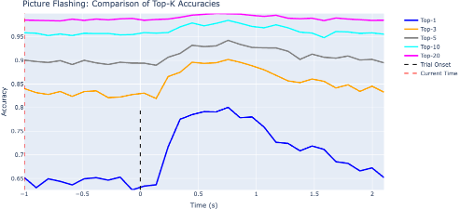

In [ ]:
# CELL 2 - Create union vocabulary
# Create union vocabulary for PF + AN + AR
print("Creating union vocabulary for cross-modality analysis...")

an_unique_words = np.unique(an_words)
ar_unique_words = np.unique(ar_words)

union_words_auditory = np.unique(np.concatenate([pf_unique_words, an_unique_words, ar_unique_words]))
union_embeddings_auditory = np.array([word_to_embedding[w] for w in union_words_auditory if w in word_to_embedding])

print(f"Cross-modality vocabulary statistics:")
print(f"  PF unique words: {len(pf_unique_words)}")
print(f"  AN unique words: {len(an_unique_words)}")
print(f"  AR unique words: {len(ar_unique_words)}")
print(f"  Union vocabulary: {len(union_words_auditory)}")
print(f"  Union embeddings: {len(union_embeddings_auditory)}")

In [ ]:
# CELL 3 - Test PF model on AN
# Test PF model on Auditory Naming (AN)
print(f"\nTesting PF model on Auditory Naming...")

pf_to_an_top_k_acc = {k: [] for k in top_k_values}
pf_to_an_r2_scores = []

for time_bin in range(an_neural.shape[1]):
    # Extract test data from AN at this time bin
    if n_bins_history > 0:
        start_bin = time_bin - n_bins_history + 1
        end_bin = time_bin + 1
        
        # Pad with the first time bin if we don't have enough history
        if start_bin < 0:
            # Extract available bins
            available_data = an_neural[:, 0:end_bin, :]  # From bin 0 to current
            # Pad by repeating the first bin
            n_pad = abs(start_bin)
            pad_data = np.tile(an_neural[:, 0:1, :], (1, n_pad, 1))
            # Concatenate padding with available data
            X_test_an = np.concatenate([pad_data, available_data], axis=1).reshape(len(an_embeddings), -1)
        else:
            X_test_an = an_neural[:, start_bin:end_bin, :].reshape(len(an_embeddings), -1)
    else:
        X_test_an = an_neural[:, time_bin, :]
    
    y_test_an = an_embeddings
    
    # Predict using PF model
    y_pred_reduced = regressor_cross.predict(X_test_an)
    y_pred = y_reducer_cross.inverse_transform(y_pred_reduced)
    
    # Compute RÂ² score
    y_test_reduced = y_reducer_cross.transform(y_test_an)
    r2 = regressor_cross.score(X_test_an, y_test_reduced)
    pf_to_an_r2_scores.append(r2)
    
    # Compute top-k accuracy using UNION vocabulary
    for k in top_k_values:
        # For each prediction, compute distances to all union embeddings
        distances_to_union = np.sum((y_pred[:, np.newaxis, :] - union_embeddings_auditory[np.newaxis, :, :]) ** 2, axis=2)
        distances_to_true = np.sum((y_pred - y_test_an) ** 2, axis=1)
        
        # Count how many union embeddings are <= distance to true
        is_closer_or_equal = distances_to_union <= distances_to_true[:, np.newaxis]
        ranks = is_closer_or_equal.sum(axis=1)
        
        # Top-k accuracy
        in_top_k = (ranks <= k).sum()
        acc = in_top_k / len(y_pred) if len(y_pred) > 0 else 0.0
        pf_to_an_top_k_acc[k].append(acc)

pf_to_an_r2_scores = np.array(pf_to_an_r2_scores)
for k in top_k_values:
    pf_to_an_top_k_acc[k] = np.array(pf_to_an_top_k_acc[k])

print(f"âœ“ Tested PF model on all {an_neural.shape[1]} AN time bins")
print(f"  Cross-modality RÂ² range: {pf_to_an_r2_scores.min():.3f} to {pf_to_an_r2_scores.max():.3f}")
print(f"  Cross-modality Top-1 range: {pf_to_an_top_k_acc[1].min():.3f} to {pf_to_an_top_k_acc[1].max():.3f}")

In [ ]:
# CELL 4 - Test PF model on AR
# Test PF model on Auditory Repetition (AR)
print(f"\nTesting PF model on Auditory Repetition...")

pf_to_ar_top_k_acc = {k: [] for k in top_k_values}
pf_to_ar_r2_scores = []

for time_bin in range(ar_neural.shape[1]):
    # Extract test data from AR at this time bin
    if n_bins_history > 0:
        start_bin = time_bin - n_bins_history + 1
        end_bin = time_bin + 1
        
        # Pad with the first time bin if we don't have enough history
        if start_bin < 0:
            # Extract available bins
            available_data = ar_neural[:, 0:end_bin, :]  # From bin 0 to current
            # Pad by repeating the first bin
            n_pad = abs(start_bin)
            pad_data = np.tile(ar_neural[:, 0:1, :], (1, n_pad, 1))
            # Concatenate padding with available data
            X_test_ar = np.concatenate([pad_data, available_data], axis=1).reshape(len(ar_embeddings), -1)
        else:
            X_test_ar = ar_neural[:, start_bin:end_bin, :].reshape(len(ar_embeddings), -1)
    else:
        X_test_ar = ar_neural[:, time_bin, :]
    
    y_test_ar = ar_embeddings
    
    # Predict using PF model
    y_pred_reduced = regressor_cross.predict(X_test_ar)
    y_pred = y_reducer_cross.inverse_transform(y_pred_reduced)
    
    # Compute RÂ² score
    y_test_reduced = y_reducer_cross.transform(y_test_ar)
    r2 = regressor_cross.score(X_test_ar, y_test_reduced)
    pf_to_ar_r2_scores.append(r2)
    
    # Compute top-k accuracy using UNION vocabulary
    for k in top_k_values:
        # For each prediction, compute distances to all union embeddings
        distances_to_union = np.sum((y_pred[:, np.newaxis, :] - union_embeddings_auditory[np.newaxis, :, :]) ** 2, axis=2)
        distances_to_true = np.sum((y_pred - y_test_ar) ** 2, axis=1)
        
        # Count how many union embeddings are <= distance to true
        is_closer_or_equal = distances_to_union <= distances_to_true[:, np.newaxis]
        ranks = is_closer_or_equal.sum(axis=1)
        
        # Top-k accuracy
        in_top_k = (ranks <= k).sum()
        acc = in_top_k / len(y_pred) if len(y_pred) > 0 else 0.0
        pf_to_ar_top_k_acc[k].append(acc)

pf_to_ar_r2_scores = np.array(pf_to_ar_r2_scores)
for k in top_k_values:
    pf_to_ar_top_k_acc[k] = np.array(pf_to_ar_top_k_acc[k])

print(f"âœ“ Tested PF model on all {ar_neural.shape[1]} AR time bins")
print(f"  Cross-modality RÂ² range: {pf_to_ar_r2_scores.min():.3f} to {pf_to_ar_r2_scores.max():.3f}")
print(f"  Cross-modality Top-1 range: {pf_to_ar_top_k_acc[1].min():.3f} to {pf_to_ar_top_k_acc[1].max():.3f}")

# CELL 5 - Markdown
### Visualize Cross-Modality Results (PF â†’ Auditory Tasks)

In [ ]:
# CELL 6 - Get timing parameters
# Get timing parameters for auditory tasks
an_n_bins = an_neural.shape[1]
an_back = np.nanmean(an_data['clean_trial_onset'])
an_forward = an_n_bins * bin_size / 1000 - np.nanmean(an_data['clean_trial_onset'])

ar_n_bins = ar_neural.shape[1]
ar_back = np.nanmean(ar_data['clean_trial_onset'])
ar_forward = ar_n_bins * bin_size / 1000 - np.nanmean(ar_data['clean_trial_onset'])

print(f"Auditory Naming - Time bins: {an_n_bins}, Time range: {an_back:.2f}s to {an_forward:.2f}s")
print(f"Auditory Repetition - Time bins: {ar_n_bins}, Time range: {ar_back:.2f}s to {ar_forward:.2f}s")

In [ ]:
# CELL 7 - Plot PFâ†’AN RÂ²
# Plot PFâ†’AN cross-modality RÂ² scores
print("\nPlotting PFâ†’AN cross-modality RÂ² scores...")

fig_pf_an_r2, ax_pf_an_r2 = plot_accuracy_plotly(
    pf_to_an_r2_scores,
    back=an_back,
    forward=an_forward,
    lines=[0],
    line_labels=['AN Trial Onset'],
    tick_interval=0.5,
    title=f'Cross-Modality: PF Peak (bin {pf_peak_bin}) â†’ AN All Bins (RÂ² Score)',
    ylabel='RÂ² Score',
    data_labels=[f'PFâ†’AN (trained at bin {pf_peak_bin})']
)
fig_pf_an_r2.show()

In [ ]:
# CELL 8 - Plot PFâ†’AN Top-K
# Plot PFâ†’AN cross-modality top-K accuracy
print("Plotting PFâ†’AN cross-modality top-K accuracy...")

pf_an_topk_data = [pf_to_an_top_k_acc[k] for k in top_k_values]
pf_an_topk_labels = [f'Top-{k}' for k in top_k_values]

fig_pf_an_topk, ax_pf_an_topk = plot_accuracy_plotly(
    pf_an_topk_data[0],
    *pf_an_topk_data[1:],
    back=an_back,
    forward=an_forward,
    lines=[0],
    line_labels=['AN Trial Onset'],
    tick_interval=0.5,
    title=f'Cross-Modality: PF Peak (bin {pf_peak_bin}) â†’ AN All Bins (Top-K Accuracy)',
    ylabel='Top-K Accuracy',
    data_labels=pf_an_topk_labels
)
fig_pf_an_topk.show()

In [ ]:
# CELL 9 - Plot PFâ†’AR RÂ²
# Plot PFâ†’AR cross-modality RÂ² scores
print("Plotting PFâ†’AR cross-modality RÂ² scores...")

fig_pf_ar_r2, ax_pf_ar_r2 = plot_accuracy_plotly(
    pf_to_ar_r2_scores,
    back=ar_back,
    forward=ar_forward,
    lines=[0],
    line_labels=['AR Trial Onset'],
    tick_interval=0.5,
    title=f'Cross-Modality: PF Peak (bin {pf_peak_bin}) â†’ AR All Bins (RÂ² Score)',
    ylabel='RÂ² Score',
    data_labels=[f'PFâ†’AR (trained at bin {pf_peak_bin})']
)
fig_pf_ar_r2.show()

In [ ]:
# CELL 10 - Plot PFâ†’AR Top-K
# Plot PFâ†’AR cross-modality top-K accuracy
print("Plotting PFâ†’AR cross-modality top-K accuracy...")

pf_ar_topk_data = [pf_to_ar_top_k_acc[k] for k in top_k_values]
pf_ar_topk_labels = [f'Top-{k}' for k in top_k_values]

fig_pf_ar_topk, ax_pf_ar_topk = plot_accuracy_plotly(
    pf_ar_topk_data[0],
    *pf_ar_topk_data[1:],
    back=ar_back,
    forward=ar_forward,
    lines=[0],
    line_labels=['AR Trial Onset'],
    tick_interval=0.5,
    title=f'Cross-Modality: PF Peak (bin {pf_peak_bin}) â†’ AR All Bins (Top-K Accuracy)',
    ylabel='Top-K Accuracy',
    data_labels=pf_ar_topk_labels
)
fig_pf_ar_topk.show()